# Painel de Análise de Vendas — atividades 1 a 20
Resolução das páginas 67 e 68. **Dados fictícios**, gerados com semente fixa para reproduzir os resultados.

No Google Colab, abra este notebook e escolha **Ambiente de execução → Executar tudo**. O código cria `vendas.csv`, a pasta `graficos/`, `resumo_analitico.csv` e um relatório com comentários.

Cada linha representa uma venda de um único produto. Por isso, o número de vendas é a contagem de linhas. Região e categoria foram incluídas para atender às atividades 13 e 15. A média de quantidade pode ser fracionária: ela é usada conforme solicitado pelo exercício, sem arredondamento artificial.

## 1. Importar as bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from matplotlib.ticker import FuncFormatter
from IPython.display import display

PASTA = Path('graficos')
PASTA.mkdir(exist_ok=True)
def moeda(valor):
    return ('R$ ' + f'{valor:,.2f}').replace(',', 'X').replace('.', ',').replace('X', '.')

## 2. Criar e carregar o CSV
A base contém vendas ao longo dos 12 meses de 2024 e alguns valores ausentes para praticar o tratamento.

In [2]:
rng = np.random.default_rng(42)
catalogo = pd.DataFrame({
    'produto': ['Notebook', 'Mouse', 'Teclado', 'Monitor', 'Cadeira', 'Mesa', 'Fone', 'Webcam'],
    'categoria': ['Informática', 'Acessórios', 'Acessórios', 'Informática', 'Móveis', 'Móveis', 'Acessórios', 'Acessórios'],
    'preco_base': [3500, 80, 150, 1100, 700, 900, 180, 250]
})
lojas = {'Loja Belo Horizonte': 'Sudeste', 'Loja São Paulo': 'Sudeste',
         'Loja Salvador': 'Nordeste', 'Loja Curitiba': 'Sul'}
n = 360
dados = pd.DataFrame({
    'data': pd.Timestamp('2024-01-01') + pd.to_timedelta(rng.integers(0, 366, n), unit='D'),
    'loja': rng.choice(list(lojas), n),
    'produto': rng.choice(catalogo['produto'], n),
    'quantidade': rng.integers(1, 11, n).astype(float)
}).merge(catalogo, on='produto', how='left')
dados['regiao'] = dados['loja'].map(lojas)
dados['preco_unitario'] = (dados.pop('preco_base') * rng.uniform(0.85, 1.15, n)).round(2)
dados.loc[[3, 45, 89], 'quantidade'] = np.nan
dados.loc[[10, 70, 120], 'preco_unitario'] = np.nan
dados.to_csv('vendas.csv', index=False)

# Para usar outra base, substitua a criação acima pelo upload do seu CSV.
df = pd.read_csv('vendas.csv')
df['data'] = pd.to_datetime(df['data'], errors='raise')
display(df.head())

        data                 loja  ...   regiao  preco_unitario
0 2024-02-02        Loja Curitiba  ...      Sul           80.31
1 2024-10-10        Loja Curitiba  ...      Sul          244.97
2 2024-08-27  Loja Belo Horizonte  ...  Sudeste          154.94
3 2024-06-09        Loja Curitiba  ...      Sul         3982.76
4 2024-06-07  Loja Belo Horizonte  ...  Sudeste          158.56

[5 rows x 7 columns]


## 3. Criar a coluna faturamento

In [3]:
df['faturamento'] = df['quantidade'] * df['preco_unitario']
display(df.head())

        data                 loja  ... preco_unitario  faturamento
0 2024-02-02        Loja Curitiba  ...          80.31       803.10
1 2024-10-10        Loja Curitiba  ...         244.97      2449.70
2 2024-08-27  Loja Belo Horizonte  ...         154.94      1549.40
3 2024-06-09        Loja Curitiba  ...        3982.76          NaN
4 2024-06-07  Loja Belo Horizonte  ...         158.56       475.68

[5 rows x 8 columns]


## 4. Verificar a integridade

In [4]:
df.info()
print('\nValores ausentes por coluna:')
print(df.isnull().sum())
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   data            360 non-null    datetime64[ns]
 1   loja            360 non-null    object        
 2   produto         360 non-null    object        
 3   quantidade      357 non-null    float64       
 4   categoria       360 non-null    object        
 5   regiao          360 non-null    object        
 6   preco_unitario  357 non-null    float64       
 7   faturamento     354 non-null    float64       
dtypes: datetime64[ns](1), float64(3), object(4)
memory usage: 22.6+ KB

Valores ausentes por coluna:
data              0
loja              0
produto           0
quantidade        3
categoria         0
regiao            0
preco_unitario    3
faturamento       6
dtype: int64
                                data  quantidade  preco_unitario   faturamento
count                 

## 5. Preencher valores nulos com a média
O faturamento é recalculado para refletir os valores preenchidos. A média global de preços atende ao enunciado, mas pode distorcer preços de produtos muito diferentes.

In [5]:
for coluna in ['quantidade', 'preco_unitario']:
    df[coluna] = df[coluna].fillna(df[coluna].mean())
df['faturamento'] = df['quantidade'] * df['preco_unitario']
print(df.isnull().sum())

data              0
loja              0
produto           0
quantidade        0
categoria         0
regiao            0
preco_unitario    0
faturamento       0
dtype: int64


## 6. Faturamento por loja, do maior para o menor

In [6]:
faturamento_loja = df.groupby('loja')['faturamento'].sum().sort_values(ascending=False)
display(faturamento_loja.to_frame())

                       faturamento
loja                              
Loja Curitiba        643897.043333
Loja Salvador        507717.892745
Loja Belo Horizonte  500695.231989
Loja São Paulo       378298.823585


## 7. Ticket médio por loja

In [7]:
resumo_loja = df.groupby('loja').agg(faturamento=('faturamento', 'sum'), numero_vendas=('loja', 'size'))
resumo_loja['ticket_medio'] = resumo_loja['faturamento'] / resumo_loja['numero_vendas']
display(resumo_loja.sort_values('ticket_medio', ascending=False))

                       faturamento  numero_vendas  ticket_medio
loja                                                           
Loja Curitiba        643897.043333             99   6504.010539
Loja Salvador        507717.892745             90   5641.309919
Loja Belo Horizonte  500695.231989             94   5326.545021
Loja São Paulo       378298.823585             77   4912.971735


## 8. Cinco produtos mais vendidos em quantidade

In [8]:
top5 = df.groupby('produto')['quantidade'].sum().sort_values(ascending=False).head(5)
display(top5.to_frame('quantidade_total'))

          quantidade_total
produto                   
Notebook         325.72549
Mesa             302.00000
Monitor          278.00000
Fone             266.72549
Cadeira          233.00000


## 9. Mês com maior e menor faturamento
Agrupamos por ano e mês juntos para não misturar meses de anos diferentes.

In [9]:
faturamento_mensal = df.groupby(df['data'].dt.to_period('M'))['faturamento'].sum().sort_index()
mes_maior = faturamento_mensal.idxmax()
mes_menor = faturamento_mensal.idxmin()
print('Maior:', mes_maior.strftime('%m/%Y'), moeda(faturamento_mensal.loc[mes_maior]))
print('Menor:', mes_menor.strftime('%m/%Y'), moeda(faturamento_mensal.loc[mes_menor]))

Maior: 06/2024 R$ 263.423,71
Menor: 08/2024 R$ 85.254,00


## 10. Extrair o mês da data

In [10]:
df['mes'] = df['data'].dt.month
display(df[['data', 'mes']].head())

        data  mes
0 2024-02-02    2
1 2024-10-10   10
2 2024-08-27    8
3 2024-06-09    6
4 2024-06-07    6


## 17 e 18. Tema global, cores e legibilidade
A configuração é antecipada para valer em todos os gráficos das atividades 11 a 16 e 19. Cada gráfico terá título, rótulos e formatação adequados.

In [11]:
sns.set_style('whitegrid')
sns.set_palette(sns.color_palette('deep'))
plt.rcParams.update({'figure.figsize': (10, 6), 'axes.titlesize': 14, 'axes.labelsize': 11})
cores = sns.color_palette('deep')
eixo_reais = FuncFormatter(lambda x, pos: moeda(x))
def salvar(fig, nome):
    fig.tight_layout()
    fig.savefig(PASTA / nome, dpi=160, bbox_inches='tight')
    plt.show()
    plt.close(fig)

## 11. Gráfico de barras: faturamento por loja

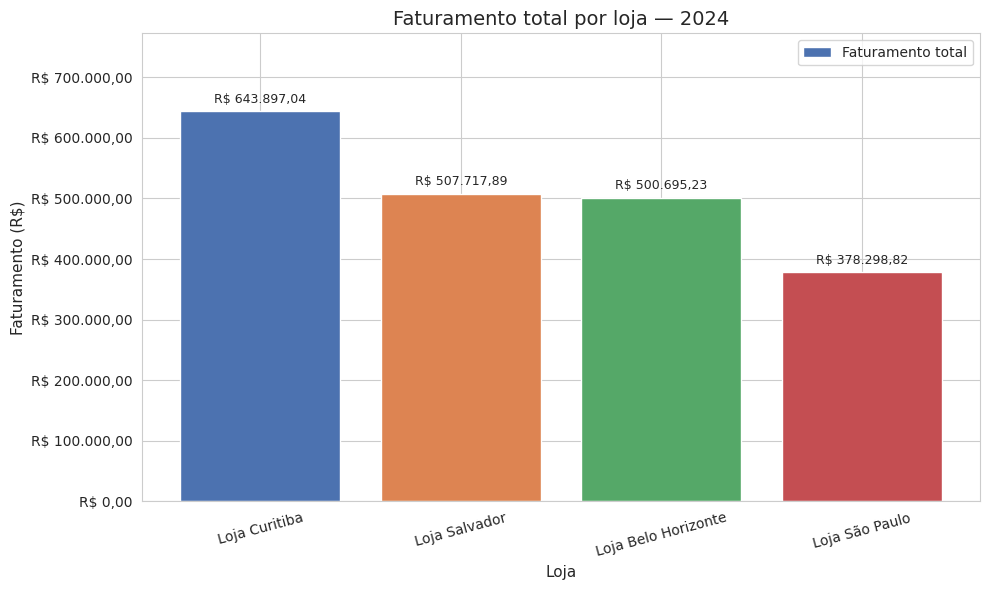

In [12]:
fig, ax = plt.subplots()
barras = ax.bar(faturamento_loja.index, faturamento_loja.values, color=cores[:len(faturamento_loja)], label='Faturamento total')
ax.set(title='Faturamento total por loja — 2024', xlabel='Loja', ylabel='Faturamento (R$)')
ax.yaxis.set_major_formatter(eixo_reais)
ax.tick_params(axis='x', rotation=15)
ax.bar_label(barras, labels=[moeda(v) for v in faturamento_loja], padding=4, fontsize=9)
ax.margins(y=0.2)
ax.legend()
salvar(fig, 'faturamento_por_loja.png')

## 12. Gráfico de linhas: evolução mensal do faturamento

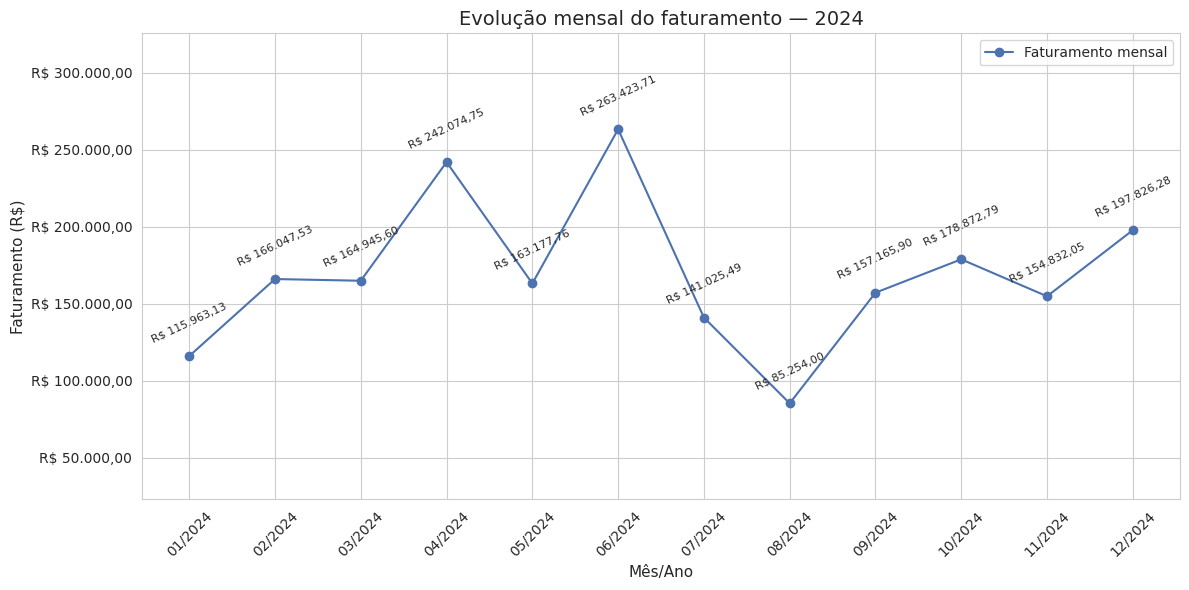

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(faturamento_mensal))
ax.plot(x, faturamento_mensal.values, marker='o', label='Faturamento mensal')
ax.set_xticks(x)
ax.set_xticklabels([m.strftime('%m/%Y') for m in faturamento_mensal.index], rotation=45)
for pos, valor in zip(x, faturamento_mensal.values):
    ax.annotate(moeda(valor), (pos, valor), xytext=(0, 10), textcoords='offset points', ha='center', fontsize=8, rotation=25)
ax.set(title='Evolução mensal do faturamento — 2024', xlabel='Mês/Ano', ylabel='Faturamento (R$)')
ax.yaxis.set_major_formatter(eixo_reais)
ax.margins(y=0.35)
ax.legend()
salvar(fig, 'evolucao_mensal.png')

## 13. Gráfico de pizza: faturamento por região

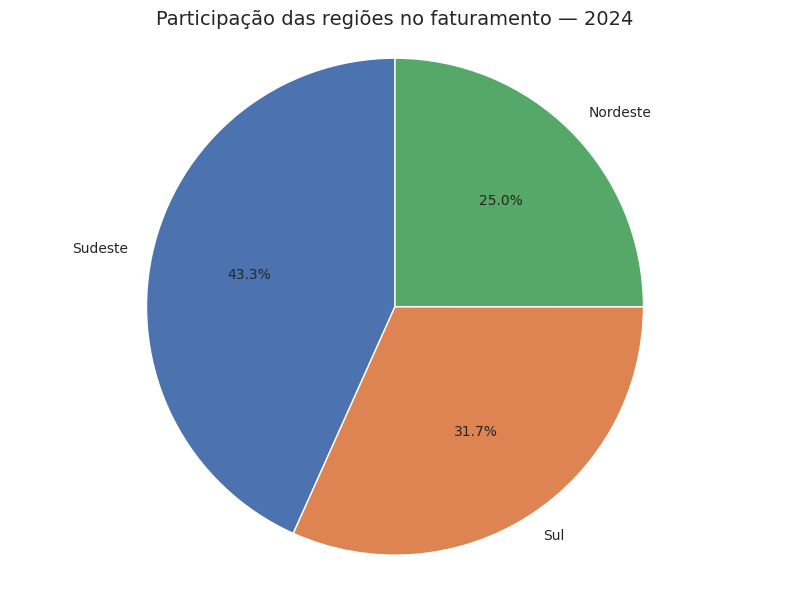

In [14]:
faturamento_regiao = df.groupby('regiao')['faturamento'].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 6))
ax.pie(faturamento_regiao, labels=faturamento_regiao.index, autopct='%1.1f%%', colors=cores[:len(faturamento_regiao)], startangle=90)
ax.set_title('Participação das regiões no faturamento — 2024')
ax.axis('equal')
salvar(fig, 'faturamento_por_regiao.png')

## 14. Dispersão: quantidade e faturamento
Pontos afastados são candidatos a análise, não erros confirmados. Produtos caros podem gerar faturamento alto mesmo com quantidades semelhantes.

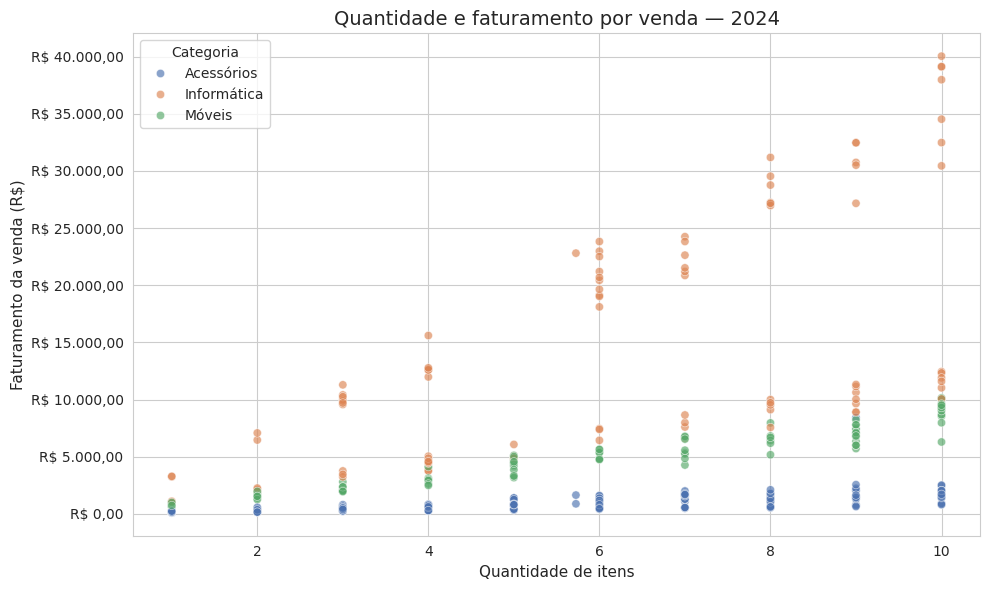

In [15]:
fig, ax = plt.subplots()
sns.scatterplot(data=df, x='quantidade', y='faturamento', hue='categoria', alpha=0.65, ax=ax)
ax.set(title='Quantidade e faturamento por venda — 2024', xlabel='Quantidade de itens', ylabel='Faturamento da venda (R$)')
ax.yaxis.set_major_formatter(eixo_reais)
ax.legend(title='Categoria')
salvar(fig, 'quantidade_faturamento.png')

## 15. Boxplot: preços por categoria

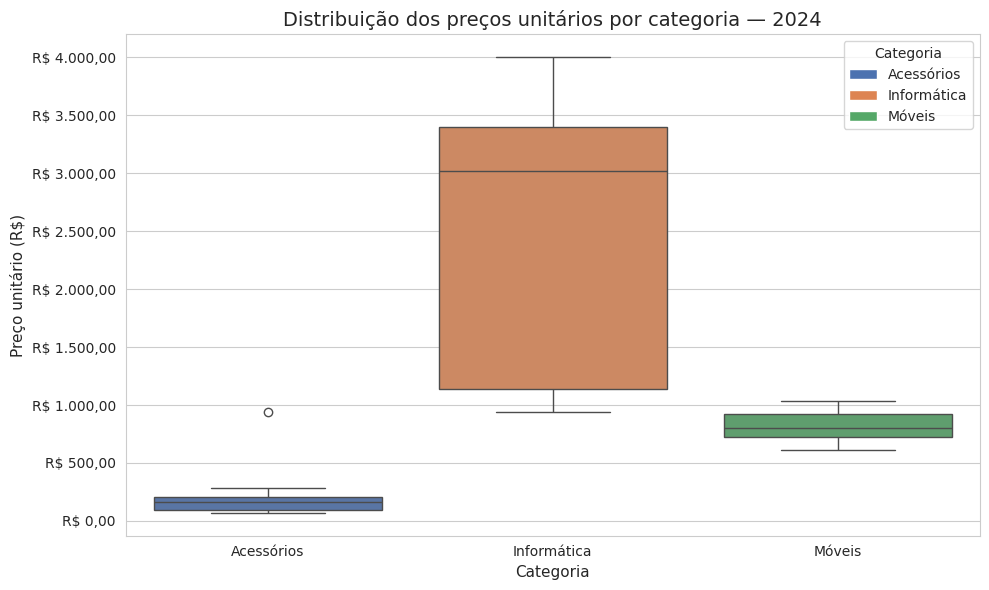

In [16]:
fig, ax = plt.subplots()
sns.boxplot(data=df, x='categoria', y='preco_unitario', hue='categoria', dodge=False, ax=ax)
ax.set(title='Distribuição dos preços unitários por categoria — 2024', xlabel='Categoria', ylabel='Preço unitário (R$)')
ax.yaxis.set_major_formatter(eixo_reais)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=cores[i], label=cat) for i, cat in enumerate(df['categoria'].unique())], title='Categoria')
salvar(fig, 'precos_por_categoria.png')

## 16. Heatmap: correlação entre variáveis numéricas
Inclui o mês solicitado na atividade 10. Correlação não demonstra causalidade; o faturamento já depende matematicamente da quantidade e do preço.

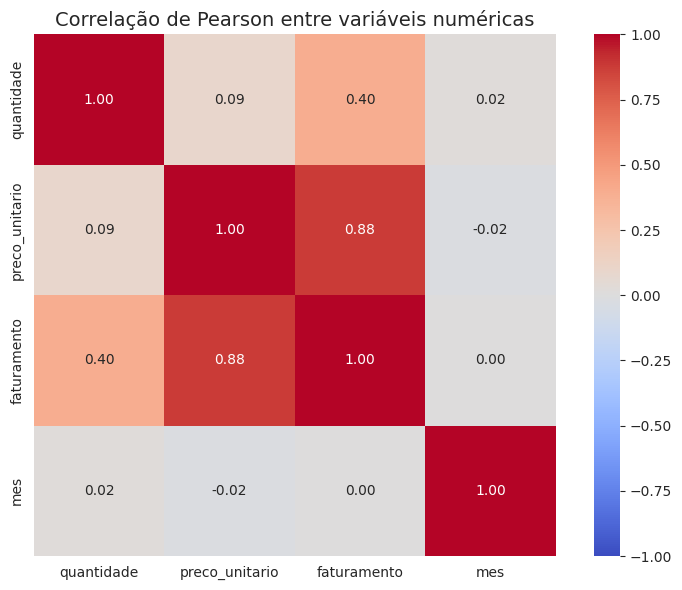

In [17]:
correlacao = df.select_dtypes(include='number').corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(correlacao, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, center=0, square=True, ax=ax)
ax.set_title('Correlação de Pearson entre variáveis numéricas')
salvar(fig, 'correlacao.png')

## 19. Layout com múltiplos gráficos

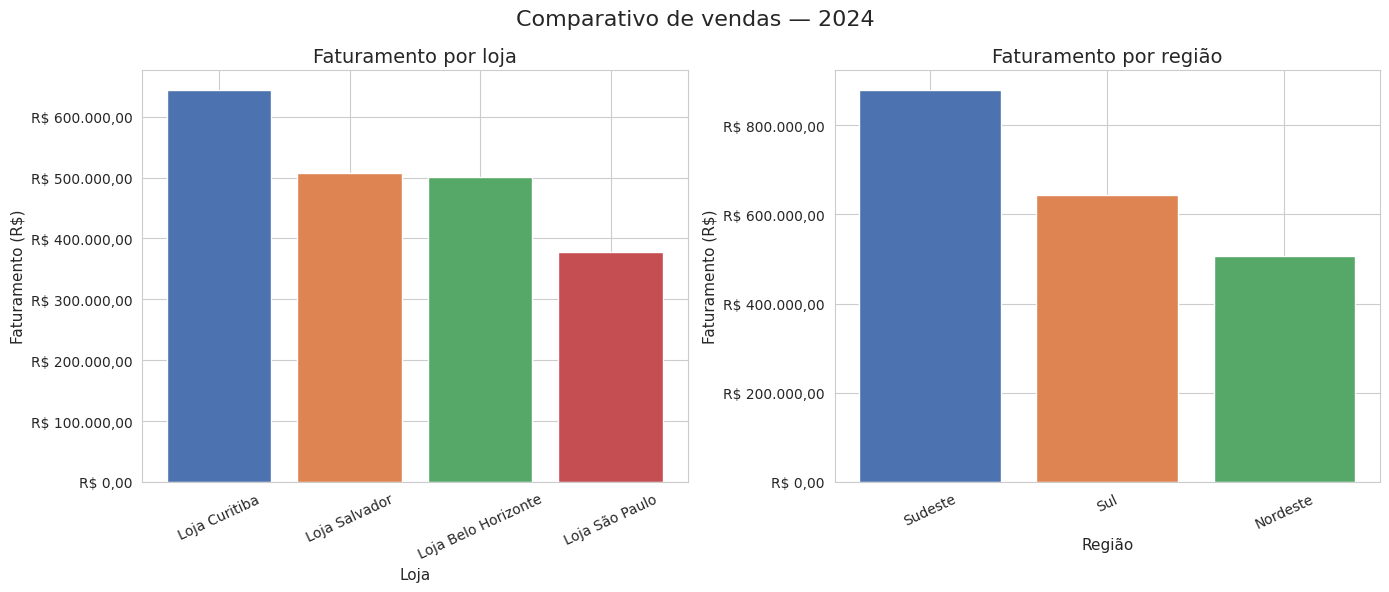

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, serie, titulo, rotulo in [
    (axes[0], faturamento_loja, 'Faturamento por loja', 'Loja'),
    (axes[1], faturamento_regiao, 'Faturamento por região', 'Região')
]:
    ax.bar(serie.index, serie.values, color=cores[:len(serie)])
    ax.set(title=titulo, xlabel=rotulo, ylabel='Faturamento (R$)')
    ax.yaxis.set_major_formatter(eixo_reais)
    ax.tick_params(axis='x', rotation=25)
fig.suptitle('Comparativo de vendas — 2024', fontsize=16)
salvar(fig, 'painel_comparativo.png')

## 20. Exportação e relatório final
Todos os gráficos foram salvos em `graficos/`. O resumo usa uma linha por indicador, preservando o significado de cada valor.

In [19]:
linhas = []
def adicionar(indicador, grupo, valor, unidade):
    linhas.append({'indicador': indicador, 'grupo': grupo, 'valor': valor, 'unidade': unidade})
adicionar('Faturamento total', 'Todas as lojas', df['faturamento'].sum(), 'R$')
adicionar('Número de vendas', 'Todas as lojas', len(df), 'vendas')
adicionar('Ticket médio geral', 'Todas as lojas', df['faturamento'].mean(), 'R$ por venda')
for loja, linha in resumo_loja.iterrows():
    adicionar('Faturamento por loja', loja, linha['faturamento'], 'R$')
    adicionar('Número de vendas por loja', loja, linha['numero_vendas'], 'vendas')
    adicionar('Ticket médio por loja', loja, linha['ticket_medio'], 'R$ por venda')
for produto, valor in top5.items():
    adicionar('Top 5 produtos em quantidade', produto, valor, 'itens')
for mes, valor in faturamento_mensal.items():
    adicionar('Faturamento mensal', mes.strftime('%m/%Y'), valor, 'R$')
for regiao, valor in faturamento_regiao.items():
    adicionar('Faturamento por região', regiao, valor, 'R$')
adicionar('Mês de maior faturamento', mes_maior.strftime('%m/%Y'), faturamento_mensal.loc[mes_maior], 'R$')
adicionar('Mês de menor faturamento', mes_menor.strftime('%m/%Y'), faturamento_mensal.loc[mes_menor], 'R$')
resumo = pd.DataFrame(linhas)
resumo.to_csv('resumo_analitico.csv', index=False, sep=';', decimal=',', encoding='utf-8-sig')
display(resumo)

regiao_lider = faturamento_regiao.idxmax()
categoria_variacao = df.groupby('categoria')['preco_unitario'].agg(lambda s: s.quantile(.75) - s.quantile(.25)).idxmax()
relatorio = f"""RELATÓRIO FINAL — DADOS FICTÍCIOS DE 2024
1. Faturamento total: {moeda(df['faturamento'].sum())}, em {len(df)} vendas.
2. A loja líder em faturamento foi {faturamento_loja.idxmax()}, com {moeda(faturamento_loja.max())}.
3. O maior ticket médio foi o da {resumo_loja['ticket_medio'].idxmax()}: {moeda(resumo_loja['ticket_medio'].max())}.
4. O produto mais vendido em quantidade foi {top5.idxmax()}, com {top5.max():.2f} itens após imputação.
5. O pico mensal ocorreu em {mes_maior.strftime('%m/%Y')}: {moeda(faturamento_mensal.max())}. O menor faturamento ocorreu em {mes_menor.strftime('%m/%Y')}: {moeda(faturamento_mensal.min())}.
6. A região {regiao_lider} respondeu por {faturamento_regiao.max()/df['faturamento'].sum():.1%} do faturamento. Ela deve ser comparada considerando também a quantidade de lojas em cada região.
7. A correlação quantidade/faturamento foi {correlacao.loc['quantidade', 'faturamento']:.2f}. A dispersão também reflete diferenças de preços entre os produtos.
8. A categoria {categoria_variacao} apresentou o maior intervalo entre o primeiro e o terceiro quartis dos preços no boxplot.
9. Valores extremos merecem investigação, mas não devem ser removidos automaticamente. A substituição pela média global pode afetar os gráficos e indicadores.
10. A variação de apenas um ano fictício não comprova sazonalidade nem permite conclusões sobre vendas reais.
"""
print(relatorio)
Path('relatorio_final.txt').write_text(relatorio, encoding='utf-8')
print('Arquivos gerados: vendas.csv, resumo_analitico.csv, relatorio_final.txt e 7 gráficos na pasta graficos/.')

                       indicador  ...       unidade
0              Faturamento total  ...            R$
1               Número de vendas  ...        vendas
2             Ticket médio geral  ...  R$ por venda
3           Faturamento por loja  ...            R$
4      Número de vendas por loja  ...        vendas
5          Ticket médio por loja  ...  R$ por venda
6           Faturamento por loja  ...            R$
7      Número de vendas por loja  ...        vendas
8          Ticket médio por loja  ...  R$ por venda
9           Faturamento por loja  ...            R$
10     Número de vendas por loja  ...        vendas
11         Ticket médio por loja  ...  R$ por venda
12          Faturamento por loja  ...            R$
13     Número de vendas por loja  ...        vendas
14         Ticket médio por loja  ...  R$ por venda
15  Top 5 produtos em quantidade  ...         itens
16  Top 5 produtos em quantidade  ...         itens
17  Top 5 produtos em quantidade  ...         itens
18  Top 5 pr

### Baixar os resultados no Colab (opcional)
Execute a célula abaixo após as atividades. Ela reúne os resultados em um arquivo ZIP.

In [20]:
from zipfile import ZipFile
with ZipFile('resultados_vendas.zip', 'w') as pacote:
    for nome in ['vendas.csv', 'resumo_analitico.csv', 'relatorio_final.txt']:
        pacote.write(nome)
    for arquivo in sorted(PASTA.glob('*.png')):
        pacote.write(arquivo)
try:
    from google.colab import files
    files.download('resultados_vendas.zip')
except ImportError:
    print('Resultados reunidos em resultados_vendas.zip.')

Resultados reunidos em resultados_vendas.zip.
